In [1]:
# 03. Архитектура и обучение модели GraphSAGE
#Прогнозирование управляющих воздействий (`Pab1`, `Pab2`, `Pab3`) с использованием GraphSAGE.

In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.11.0+cpu
CUDA available: False


In [3]:

df = pd.read_csv('../data/wtbdata_245days.csv')
loc = pd.read_csv('../data/sdwpf_baidukddcup2022_turb_location.csv')

# Загрузка графа
graph_data = torch.load('../results/graph_data.pt')
edge_index = graph_data['edge_index']
print(f"Данные загружены: {df.shape}, Турбин: {df['TurbID'].nunique()}")

Данные загружены: (4727520, 13), Турбин: 134


In [4]:
feature_cols = ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Patv']
target_cols = ['Pab1', 'Pab2', 'Pab3']


feature_cols = ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Patv']
target_cols = ['Pab1', 'Pab2', 'Pab3']

print("Количество NaN до обработки:")
print(df[feature_cols + target_cols].isna().sum())


df[feature_cols] = df[feature_cols].fillna(method='ffill').fillna(method='bfill')
df[target_cols] = df[target_cols].fillna(method='ffill').fillna(method='bfill')

print(f"Осталось NaN после заполнения: {df[feature_cols + target_cols].isna().sum().sum()}")


scaler_features = StandardScaler()
scaler_targets = StandardScaler()

df[feature_cols] = scaler_features.fit_transform(df[feature_cols])
df[target_cols] = scaler_targets.fit_transform(df[target_cols])

print("✅ NaN обработаны + нормализация завершена")

Количество NaN до обработки:
Wspd    49518
Wdir    49518
Etmp    49518
Itmp    49518
Patv    49518
Pab1    49518
Pab2    49518
Pab3    49518
dtype: int64
Осталось NaN после заполнения: 0
✅ NaN обработаны + нормализация завершена


In [5]:
# === 3.1 Построение PyG Data объектов (time-series + graph) ===
import torch
from torch_geometric.data import Data
from torch.utils.data import Dataset, DataLoader

class WindGraphDataset(Dataset):
    def __init__(self, df, edge_index, seq_len=6, pred_len=1):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.edge_index = edge_index
        
        
    
        self.turb_groups = [group for _, group in df.groupby('TurbID')]
        
    def __len__(self):
        return len(self.turb_groups[0]) - self.seq_len - self.pred_len + 1
    
    def __getitem__(self, idx):
 
        features = []
        targets = []
        for g in self.turb_groups:
            seq = g.iloc[idx:idx+self.seq_len]
            target = g.iloc[idx+self.seq_len:idx+self.seq_len+self.pred_len]
            
            feat = seq[['Wspd','Wdir','Etmp','Itmp','Patv']].values 
            tgt = target[['Pab1','Pab2','Pab3']].values
            
            features.append(torch.tensor(feat, dtype=torch.float))
            targets.append(torch.tensor(tgt, dtype=torch.float))
        
        x = torch.stack(features) 
        y = torch.stack(targets).squeeze(1)
        
        return Data(x=x, y=y, edge_index=self.edge_index)



dataset = WindGraphDataset(df, edge_index)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, len(dataset)-train_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

In [6]:
class GraphSAGEWind(torch.nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, out_channels=3, num_layers=3):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers-1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.lin = torch.nn.Linear(hidden_channels, out_channels)
        
    def forward(self, data):
        x = data.x.mean(dim=1)  
        for conv in self.convs:
            x = conv(x, data.edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.2, training=self.training)
        return self.lin(x)

model = GraphSAGEWind()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

In [7]:
# === 3.2 РАЗДЕЛЕНИЕ ДАННЫХ БЕЗ УТЕЧКИ ===

from torch_geometric.loader import DataLoader as PyGDataLoader


total_days = df['Day'].max()

train_days = 20      # сколько дней берём на обучение
test_days = 30       # сколько дней оставляем на тест


train_start_day = total_days - train_days + 1
df_train = df[df['Day'] >= train_start_day].copy().reset_index(drop=True)

print(f"Обучение: дни {train_start_day} — {total_days} ({len(df_train)} записей)")
print(f"Тест (будет в 04 ноутбуке): дни {total_days - train_days - test_days + 1} — {total_days - train_days}")

# === Класс датасета ===
class WindGraphDataset(Dataset):
    def __init__(self, df, edge_index, seq_len=6, pred_len=1, max_samples=8000):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.edge_index = edge_index
        self.groups = [group.reset_index(drop=True) for _, group in df.groupby('TurbID')]
        self.num_nodes = len(self.groups)
        
        full_length = len(self.groups[0]) - seq_len - pred_len + 1
        self.length = min(full_length, max_samples)
        
        print(f"Создан датасет: {self.num_nodes} турбин, {self.length:,} окон")
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        features = []
        targets = []
        for g in self.groups:
            seq = g.iloc[idx:idx + self.seq_len]
            tgt = g.iloc[idx + self.seq_len:idx + self.seq_len + self.pred_len]
            
            feat = seq[feature_cols].values.astype(np.float32)
            target = tgt[target_cols].values.astype(np.float32)
            
            features.append(torch.from_numpy(feat))
            targets.append(torch.from_numpy(target).squeeze(0))
        
        return Data(
            x=torch.stack(features),
            y=torch.stack(targets),
            edge_index=self.edge_index.clone()
        )




dataset = WindGraphDataset(
    df=df_train, 
    edge_index=edge_index, 
    seq_len=6, 
    pred_len=1,
    max_samples=8000
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = PyGDataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
val_loader = PyGDataLoader(val_dataset, batch_size=256, shuffle=False, drop_last=True)

print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
print(f"Batch size: 128 (train) / 256 (val)")

Обучение: дни 226 — 245 (385920 записей)
Тест (будет в 04 ноутбуке): дни 196 — 225
Создан датасет: 134 турбин, 2,874 окон
Train: 2,299 | Val: 575
Batch size: 128 (train) / 256 (val)


In [8]:
# === 3.3 Архитектура модели GraphSAGE ===
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEWind(torch.nn.Module):
    def __init__(self, in_channels=5, hidden_channels=128, out_channels=3, num_layers=3, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.convs = torch.nn.ModuleList()
        
     
        self.convs.append(SAGEConv(in_channels, hidden_channels))
     
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        
        self.dropout = dropout
        self.lin = torch.nn.Linear(hidden_channels, out_channels)
        
    def forward(self, data):
        x = data.x.mean(dim=1)  
        
        for i, conv in enumerate(self.convs):
            x = conv(x, data.edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        out = self.lin(x)
        return out

model = GraphSAGEWind()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Модель создана:")
print(model)
print(f"Устройство: {device}")

Модель создана:
GraphSAGEWind(
  (convs): ModuleList(
    (0): SAGEConv(5, 128, aggr=mean)
    (1-2): 2 x SAGEConv(128, 128, aggr=mean)
  )
  (lin): Linear(in_features=128, out_features=3, bias=True)
)
Устройство: cpu


In [9]:
# === 3.4 Обучение модели ===
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = torch.nn.MSELoss()

num_epochs = 30  
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    batch_count = 0
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out, batch.y)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        batch_count += 1
    
    train_loss = train_loss / batch_count
    train_losses.append(train_loss)
    

    model.eval()
    val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            val_loss += criterion(out, batch.y).item()
            val_count += 1
    
    val_loss = val_loss / val_count if val_count > 0 else 0
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    

    if (epoch + 1) % 2 == 0 or epoch == num_epochs - 1:
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_features': scaler_features,
            'scaler_targets': scaler_targets,
            'seq_len': 6,
            'feature_cols': feature_cols,
            'target_cols': target_cols,
            'epoch': epoch + 1
        }, f'../results/graphsage_wind_model_ep{epoch+1}.pt')
        print(f"✅ Модель сохранена (эпоха {epoch+1})")
        
print("Обучение завершено!")

Epoch 1/30: 100%|██████████| 17/17 [02:51<00:00, 10.11s/it]


Epoch  1 | Train Loss: 0.821595 | Val Loss: 0.548012


Epoch 2/30: 100%|██████████| 17/17 [02:54<00:00, 10.27s/it]


Epoch  2 | Train Loss: 0.484639 | Val Loss: 0.352730
✅ Модель сохранена (эпоха 2)


Epoch 3/30: 100%|██████████| 17/17 [02:55<00:00, 10.33s/it]


...

Epoch 28 | Train Loss: 0.226694 | Val Loss: 0.188050
✅ Модель сохранена (эпоха 28)


Epoch 29/30: 100%|██████████| 17/17 [04:16<00:00, 15.10s/it]


Epoch 29 | Train Loss: 0.225865 | Val Loss: 0.183162


Epoch 30/30: 100%|██████████| 17/17 [04:27<00:00, 15.76s/it]


Epoch 30 | Train Loss: 0.221088 | Val Loss: 0.178084
✅ Модель сохранена (эпоха 30)
Обучение завершено!


In [10]:
# === 3.5 Сохранение модели и скейлеров ===


torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler_features': scaler_features,
    'scaler_targets': scaler_targets,
    'seq_len': 6,                   
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'epoch': 8,                      
    'final_train_loss': train_losses[-1],
    'final_val_loss': val_losses[-1]
}, '../results/graphsage_wind_model.pt')

print("✅ Финальная модель успешно сохранена в ../results/graphsage_wind_model.pt")



best_epoch = val_losses.index(min(val_losses)) + 1
print(f"Лучшая эпоха по Val Loss — {best_epoch} (Val Loss = {min(val_losses):.6f})")

torch.save({
    'model_state_dict': model.state_dict(),   # сейчас веса — от 8 эпохи
    'scaler_features': scaler_features,
    'scaler_targets': scaler_targets,
    'seq_len': 6,
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'epoch': best_epoch,
    'val_loss': min(val_losses)
}, '../results/graphsage_wind_model_best.pt')

print("✅ Лучшая модель (по Val Loss) сохранена в ../results/graphsage_wind_model_best.pt")

✅ Финальная модель успешно сохранена в ../results/graphsage_wind_model.pt
Лучшая эпоха по Val Loss — 30 (Val Loss = 0.178084)
✅ Лучшая модель (по Val Loss) сохранена в ../results/graphsage_wind_model_best.pt


In [11]:
# ================================================
# GCN ДЛЯ СРАВНЕНИЯ
# ================================================

from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class GCNWind(torch.nn.Module):
    def __init__(self, in_channels=5, hidden_channels=128, out_channels=3, num_layers=3, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.convs = torch.nn.ModuleList()
        
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        
        self.dropout = dropout
        self.lin = torch.nn.Linear(hidden_channels, out_channels)
        
    def forward(self, data):
        x = data.x.mean(dim=1)  
        for i, conv in enumerate(self.convs):
            x = conv(x, data.edge_index)
            x = F.relu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(x)



model_gcn = GCNWind().to(device)
optimizer_gcn = torch.optim.Adam(model_gcn.parameters(), lr=0.001, weight_decay=1e-5)
criterion = torch.nn.MSELoss()

num_epochs = 8
train_losses_gcn = []
val_losses_gcn = []

print("Начало обучения GCN...")

for epoch in range(num_epochs):
    model_gcn.train()
    train_loss = 0.0
    batch_count = 0
    
    for batch in tqdm(train_loader, desc=f"GCN Epoch {epoch+1}/{num_epochs}"):
        batch = batch.to(device)
        optimizer_gcn.zero_grad()
        
        out = model_gcn(batch)
        loss = criterion(out, batch.y)
        
        loss.backward()
        optimizer_gcn.step()
        
        train_loss += loss.item()
        batch_count += 1
    
    train_loss = train_loss / batch_count
    train_losses_gcn.append(train_loss)
    

    
    model_gcn.eval()
    val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model_gcn(batch)
            val_loss += criterion(out, batch.y).item()
            val_count += 1
    
    val_loss = val_loss / val_count if val_count > 0 else 0
    val_losses_gcn.append(val_loss)
    
    print(f"GCN Epoch {epoch+1:2d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print("✅ Обучение GCN завершено!")

Начало обучения GCN...


GCN Epoch 1/8: 100%|██████████| 17/17 [04:12<00:00, 14.85s/it]


GCN Epoch  1 | Train Loss: 1.054484 | Val Loss: 0.776017


GCN Epoch 2/8: 100%|██████████| 17/17 [04:11<00:00, 14.77s/it]


GCN Epoch  2 | Train Loss: 0.675565 | Val Loss: 0.551013


...

GCN Epoch  6 | Train Loss: 0.369805 | Val Loss: 0.330653


GCN Epoch 7/8: 100%|██████████| 17/17 [04:13<00:00, 14.90s/it]


GCN Epoch  7 | Train Loss: 0.354279 | Val Loss: 0.317556


GCN Epoch 8/8: 100%|██████████| 17/17 [03:11<00:00, 11.24s/it]


GCN Epoch  8 | Train Loss: 0.343651 | Val Loss: 0.313800
✅ Обучение GCN завершено!


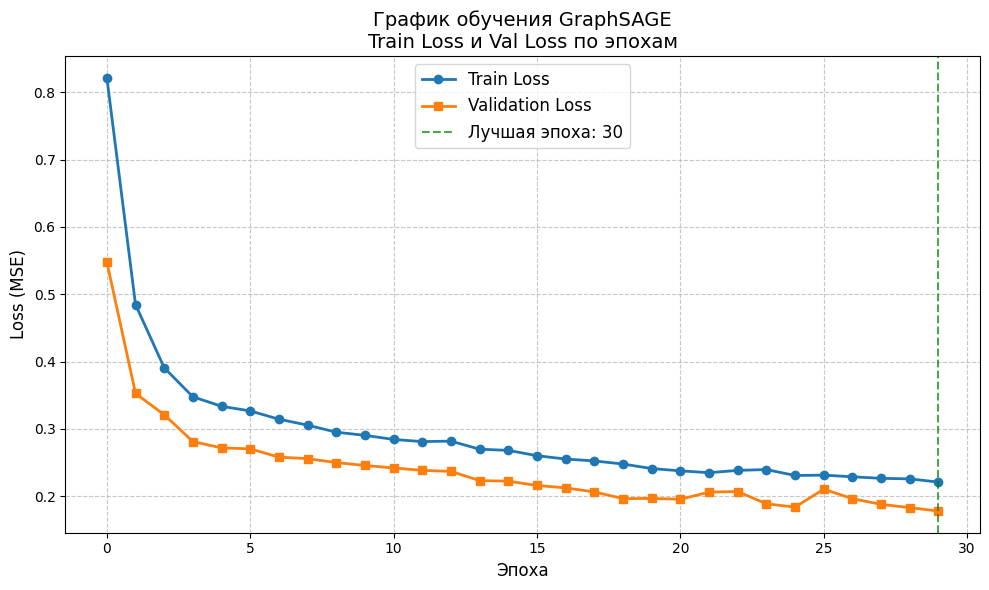

Лучшая эпоха по Val Loss: 30 (Val Loss = 0.178084)


In [12]:
# === 3.6 График обучения (Train Loss vs Val Loss) ===

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)

plt.title('График обучения GraphSAGE\nTrain Loss и Val Loss по эпохам', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Подсветка лучшей эпохи
best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Лучшая эпоха: {best_epoch+1}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Лучшая эпоха по Val Loss: {best_epoch+1} (Val Loss = {min(val_losses):.6f})")